# Chapter 02: Projective Geometry and Transformations of 2D

Source orientation: printed pages 25-64; PDF pages 43-82.

This notebook is an original computational treatment of the chapter. The source pages were used to identify the chapter sequence and notation: homogeneous points and lines, conics, homographies, transformation subgroups, cross-ratio, affine and metric rectification, pole-polar geometry, and fixed structures. No textbook prose, figures, screenshots, page crops, or exercise text are reproduced.


## Chapter Goal

Build a working 2D projective-geometry lab for multiple-view geometry. By the end, a reader should be able to represent points, lines, conics, and homographies in homogeneous coordinates; predict which measurements survive Euclidean, similarity, affine, and projective transformations; recover affine structure from a vanishing line; recover metric structure from orthogonal-line constraints; and verify the claims with executable incidence, cross-ratio, conic, and eigenstructure checks.


## Computational Translation Guide

| Book object | Computational representation | What to inspect |
| --- | --- | --- |
| Point of `P^2` | nonzero 3-vector `x`, with `x` and `lambda*x` equivalent | dehomogenized finite point when `x[2] != 0`; ideal direction when `x[2] = 0` |
| Line | 3-vector `l = (a,b,c)` with incidence `l.T @ x = 0` | intersections by `cross(l, m)` and joins by `cross(x, y)` |
| Homography | nonsingular `3 x 3` matrix `H`, up to scale | points move by `H @ x`, lines by `inv(H).T @ l` |
| Conic | symmetric matrix `C` with `x.T @ C @ x = 0` | tangent at `x` is `C @ x`; transformed conic is `inv(H).T @ C @ inv(H)` |
| Dual conic of circular points | rank-2 matrix `Cinf_star`, canonical `diag(1,1,0)` | metric angles from `l.T @ Cinf_star @ m` |
| Rectification | a homography chosen to fix an absolute object | affine: send imaged `l_inf` to `(0,0,1)`; metric: make `Cinf_star` canonical up to similarity |

All equalities involving homogeneous objects are checked as proportionality, incidence, determinant, or residual statements, not raw array equality.


## Library Routing

| Chapter concept | Representation | Library | Why this route fits |
| --- | --- | --- | --- |
| Incidence, ideal points, vanishing line | annotated 2D construction | Matplotlib + NumPy | durable labeled diagrams expose joins, meets, and line transport without hiding the algebra |
| Homography acting on a grid | interactive side-by-side line families | Plotly | panning and zooming makes finite vanishing behavior and line preservation easier to inspect |
| Synthetic perspective image and rectification | generated planar raster warped by homographies | OpenCV + Matplotlib | this is the computer-vision use case of the chapter: a plane image is rectified by projective warps |
| Cross-ratio, conic tangency, fixed points | numerical and symbolic invariant checks | NumPy + SymPy | exact formulas and small residuals make scale-invariant claims auditable |
| Invariant summaries | JSON/CSV artifacts | pandas + course artifact helpers | later QC can verify artifact existence and the numerical claims without rerunning every plot manually |


## Route Through The Chapter

1. Start with homogeneous points and lines, then use a homography to turn parallel line families into finite vanishing points.
2. Track the projective invariant that survives on a line: the cross-ratio of four collinear points.
3. Compare Euclidean, similarity, affine, and projective transformations by watching which measurements fail first.
4. Build a synthetic image of a plane, recover its vanishing line, and affinely rectify it.
5. Add orthogonal-line constraints to recover metric structure up to a similarity.
6. Use conics and fixed-point eigenstructure to connect the algebraic representation to geometric objects.


In [1]:
from pathlib import Path
import sys
import math

import cv2
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display
from matplotlib import pyplot as plt
from plotly.subplots import make_subplots

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
else:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        possible = candidate / "Multiple-View-Geometry-in-Computer-Vision"
        if (possible / "00-book-index.ipynb").exists() and (possible / "utils").exists():
            BOOK_ROOT = possible
            break
    else:
        raise RuntimeError("Could not find the MVG book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    display_artifact,
    relative_to_book,
    save_csv,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

TOPIC = "chapter-02"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / TOPIC
for child in ["figures", "interactive", "checks", "tables"]:
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(20260211)
artifact_paths = []
check_registry = {}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "font.size": 10,
})

EPS = 1e-12


def homog(points):
    pts = np.asarray(points, dtype=float)
    if pts.shape[-1] == 3:
        return pts.copy()
    ones = np.ones((*pts.shape[:-1], 1), dtype=float)
    return np.concatenate([pts, ones], axis=-1)


def dehomog(points, eps=EPS):
    pts = np.asarray(points, dtype=float)
    w = pts[..., -1:]
    safe = np.where(np.abs(w) < eps, np.sign(w) * eps + (w == 0) * eps, w)
    return pts[..., :-1] / safe


def transform_points(H, points):
    hp = homog(points)
    return (np.asarray(H, dtype=float) @ hp.T).T


def transform_points_2d(H, points):
    return dehomog(transform_points(H, points))


def join_from_2d(p, q):
    return np.cross(homog(np.asarray(p, dtype=float).reshape(1, 2))[0], homog(np.asarray(q, dtype=float).reshape(1, 2))[0])


def transform_line(H, line):
    return np.linalg.inv(np.asarray(H, dtype=float)).T @ np.asarray(line, dtype=float)


def transform_conic(H, C):
    Hinv = np.linalg.inv(np.asarray(H, dtype=float))
    return Hinv.T @ np.asarray(C, dtype=float) @ Hinv


def transform_dual_conic(H, Cstar):
    H = np.asarray(H, dtype=float)
    return H @ np.asarray(Cstar, dtype=float) @ H.T


def normalize_h(v):
    arr = np.asarray(v)
    norm = np.linalg.norm(arr)
    return arr if norm < EPS else arr / norm


def proportional_residual(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    if a.shape[0] == 3 and b.shape[0] == 3:
        return float(np.linalg.norm(np.cross(a, b)) / max(np.linalg.norm(a) * np.linalg.norm(b), EPS))
    scale = np.vdot(b, a) / max(np.vdot(b, b), EPS)
    return float(np.linalg.norm(a - scale * b) / max(np.linalg.norm(a), EPS))


def incidence_residual(line, point):
    return float(abs(np.dot(np.asarray(line, dtype=float), np.asarray(point, dtype=float))) /
                 max(np.linalg.norm(line) * np.linalg.norm(point), EPS))


def segment_for_line(line, xlim, ylim, eps=1e-10):
    a, b, c = np.asarray(line, dtype=float)
    pts = []
    for x in xlim:
        if abs(b) > eps:
            y = (-a * x - c) / b
            if ylim[0] - 1e-7 <= y <= ylim[1] + 1e-7:
                pts.append((x, y))
    for y in ylim:
        if abs(a) > eps:
            x = (-b * y - c) / a
            if xlim[0] - 1e-7 <= x <= xlim[1] + 1e-7:
                pts.append((x, y))
    unique = []
    for p in pts:
        if not any(np.linalg.norm(np.asarray(p) - np.asarray(q)) < 1e-7 for q in unique):
            unique.append(p)
    if len(unique) < 2:
        return None
    return np.asarray(max(((p, q) for i, p in enumerate(unique) for q in unique[i + 1:]),
                          key=lambda pair: np.linalg.norm(np.asarray(pair[0]) - np.asarray(pair[1]))))


def scalar_cross_ratio(t):
    t = np.asarray(t, dtype=float)
    return float(((t[0] - t[1]) * (t[2] - t[3])) / ((t[0] - t[2]) * (t[1] - t[3])))


def cross_ratio_collinear(points2d):
    pts = np.asarray(points2d, dtype=float)
    direction = pts[-1] - pts[0]
    direction = direction / np.linalg.norm(direction)
    return scalar_cross_ratio(pts @ direction)


def polygon_area(points):
    pts = np.asarray(points, dtype=float)
    x, y = pts[:, 0], pts[:, 1]
    return float(0.5 * abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))


def angle_between_lines(line_a, line_b):
    la = np.asarray(line_a, dtype=float)
    lb = np.asarray(line_b, dtype=float)
    na = la[:2]
    nb = lb[:2]
    cos_value = np.dot(na, nb) / max(np.linalg.norm(na) * np.linalg.norm(nb), EPS)
    cos_value = float(np.clip(abs(cos_value), -1.0, 1.0))
    return math.degrees(math.acos(cos_value))


def angle_from_dual_conic(line_a, line_b, Cstar):
    la = np.asarray(line_a, dtype=float)
    lb = np.asarray(line_b, dtype=float)
    Cstar = np.asarray(Cstar, dtype=float)
    numerator = float(la.T @ Cstar @ lb)
    denom = math.sqrt(abs(float(la.T @ Cstar @ la) * float(lb.T @ Cstar @ lb)))
    cos_value = np.clip(numerator / max(denom, EPS), -1.0, 1.0)
    return math.degrees(math.acos(cos_value))


def affine_rectifier_from_line(line):
    l = np.asarray(line, dtype=float)
    if abs(l[2]) > EPS:
        l = l / l[2]
    return np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [l[0], l[1], l[2]]], dtype=float)


def inverse_sqrt_spd(S):
    values, vectors = np.linalg.eigh(np.asarray(S, dtype=float))
    if np.any(values <= 0):
        raise ValueError(f"Expected positive definite matrix, got eigenvalues {values}")
    return vectors @ np.diag(1.0 / np.sqrt(values)) @ vectors.T


def warp_image_with_bounds(image, H, pad=28, max_side=880, border=(248, 248, 248)):
    height, width = image.shape[:2]
    corners = np.array([[0, 0], [width - 1, 0], [width - 1, height - 1], [0, height - 1]], dtype=float)
    warped_corners = transform_points_2d(H, corners)
    min_xy = warped_corners.min(axis=0)
    max_xy = warped_corners.max(axis=0)
    span = np.maximum(max_xy - min_xy, 1.0)
    scale = min(max_side / span[0], max_side / span[1], 1.8)
    out_w = int(math.ceil(scale * span[0] + 2 * pad))
    out_h = int(math.ceil(scale * span[1] + 2 * pad))
    T = np.array([[scale, 0.0, pad - scale * min_xy[0]], [0.0, scale, pad - scale * min_xy[1]], [0.0, 0.0, 1.0]])
    canvas_H = T @ np.asarray(H, dtype=float)
    warped = cv2.warpPerspective(image, canvas_H, (out_w, out_h), flags=cv2.INTER_LINEAR, borderValue=border)
    return warped, canvas_H


def draw_line_on_image_axes(ax, line, image_shape, **kwargs):
    height, width = image_shape[:2]
    seg = segment_for_line(line, (0, width - 1), (0, height - 1))
    if seg is not None:
        ax.plot(seg[:, 0], seg[:, 1], **kwargs)


## Homogeneous Incidence And The Vanishing Line

Parallel lines are a Euclidean special case, not a projective one. In homogeneous coordinates two parallel finite lines still meet; their intersection has third coordinate zero and represents an ideal direction. A homography can move that ideal point to a finite vanishing point. Two independent ideal directions determine the imaged line at infinity, also called the vanishing line of the plane.


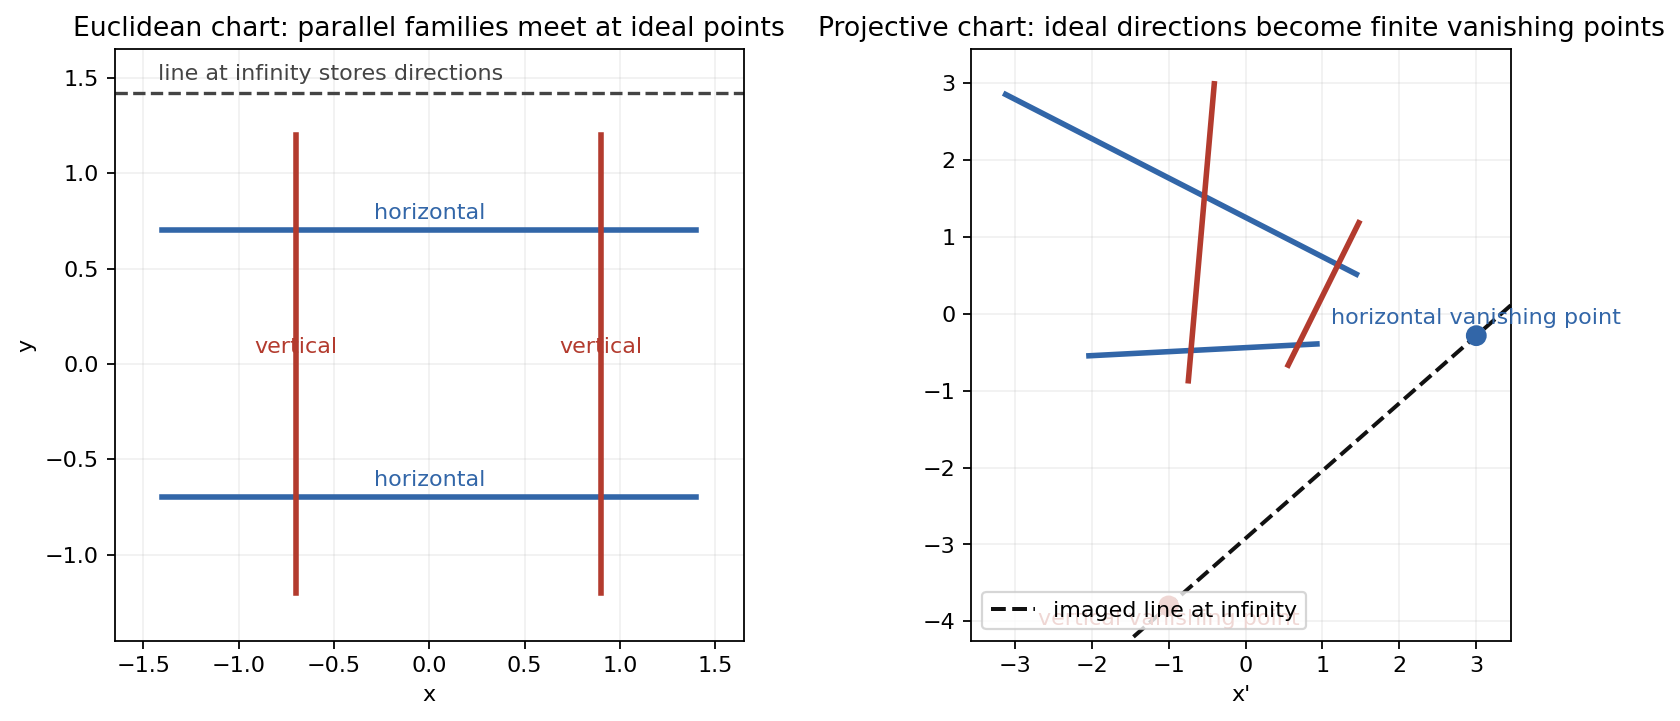

{'horizontal_ideal_source': [-1.0, 0.0, 0.0],
 'vertical_ideal_source': [0.0, 1.0, 0.0],
 'vanishing_line_matches_H_inverse_transpose': 6.338043416629161e-17,
 'max_transformed_endpoint_incidence': 1.1269543052411977e-16,
 'vanishing_points_lie_on_vanishing_line': 5.323393897948094e-17}

In [2]:
H_plane = np.array([[1.05, 0.25, 0.25], [-0.10, 0.95, 0.15], [0.35, -0.25, 1.00]])
linf = np.array([0.0, 0.0, 1.0])

source_segments = {
    "horizontal y=-0.7": np.array([[-1.4, -0.7], [1.4, -0.7]]),
    "horizontal y=0.7": np.array([[-1.4, 0.7], [1.4, 0.7]]),
    "vertical x=-0.7": np.array([[-0.7, -1.2], [-0.7, 1.2]]),
    "vertical x=0.9": np.array([[0.9, -1.2], [0.9, 1.2]]),
}
source_lines = {name: join_from_2d(*segment) for name, segment in source_segments.items()}
image_lines = {name: transform_line(H_plane, line) for name, line in source_lines.items()}
warped_segments = {name: transform_points_2d(H_plane, segment) for name, segment in source_segments.items()}

vp_horizontal = np.cross(image_lines["horizontal y=-0.7"], image_lines["horizontal y=0.7"])
vp_vertical = np.cross(image_lines["vertical x=-0.7"], image_lines["vertical x=0.9"])
vanishing_line = np.cross(vp_horizontal, vp_vertical)
linf_image = transform_line(H_plane, linf)

line_transport_residuals = []
for name, segment in source_segments.items():
    hp = transform_points(H_plane, segment)
    lp = image_lines[name]
    line_transport_residuals.extend([incidence_residual(lp, hp[0]), incidence_residual(lp, hp[1])])

vanishing_checks = {
    "horizontal_ideal_source": normalize_h(np.cross(source_lines["horizontal y=-0.7"], source_lines["horizontal y=0.7"])).round(8).tolist(),
    "vertical_ideal_source": normalize_h(np.cross(source_lines["vertical x=-0.7"], source_lines["vertical x=0.9"])).round(8).tolist(),
    "vanishing_line_matches_H_inverse_transpose": proportional_residual(vanishing_line, linf_image),
    "max_transformed_endpoint_incidence": max(line_transport_residuals),
    "vanishing_points_lie_on_vanishing_line": max(incidence_residual(vanishing_line, vp_horizontal), incidence_residual(vanishing_line, vp_vertical)),
}
check_registry["homogeneous_incidence_vanishing_line"] = vanishing_checks

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
colors = {"horizontal y=-0.7": "#3266a8", "horizontal y=0.7": "#3266a8", "vertical x=-0.7": "#b33b2e", "vertical x=0.9": "#b33b2e"}
for name, segment in source_segments.items():
    axes[0].plot(segment[:, 0], segment[:, 1], color=colors[name], linewidth=2.5)
    mid = segment.mean(axis=0)
    axes[0].text(mid[0], mid[1] + 0.06, name.split()[0], color=colors[name], ha="center")
axes[0].axhline(1.42, color="#444444", linestyle="--", linewidth=1.5)
axes[0].text(-1.42, 1.49, "line at infinity stores directions", color="#444444")
axes[0].set_title("Euclidean chart: parallel families meet at ideal points")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-1.65, 1.65)
axes[0].set_ylim(-1.45, 1.65)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

all_warped = np.vstack(list(warped_segments.values()))
vp_xy = dehomog(np.vstack([vp_horizontal, vp_vertical]))
plot_points = np.vstack([all_warped, vp_xy])
margin = 0.45
xlim = (plot_points[:, 0].min() - margin, plot_points[:, 0].max() + margin)
ylim = (plot_points[:, 1].min() - margin, plot_points[:, 1].max() + margin)
for name, segment in warped_segments.items():
    axes[1].plot(segment[:, 0], segment[:, 1], color=colors[name], linewidth=2.5)
axes[1].scatter(vp_xy[:, 0], vp_xy[:, 1], s=70, color=["#3266a8", "#b33b2e"], zorder=5)
axes[1].text(vp_xy[0, 0], vp_xy[0, 1] + 0.15, "horizontal vanishing point", color="#3266a8", ha="center")
axes[1].text(vp_xy[1, 0], vp_xy[1, 1] - 0.25, "vertical vanishing point", color="#b33b2e", ha="center")
seg = segment_for_line(vanishing_line, xlim, ylim)
if seg is not None:
    axes[1].plot(seg[:, 0], seg[:, 1], color="#111111", linestyle="--", linewidth=1.8, label="imaged line at infinity")
axes[1].set_title("Projective chart: ideal directions become finite vanishing points")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlim(*xlim)
axes[1].set_ylim(*ylim)
axes[1].set_xlabel("x'")
axes[1].legend(loc="lower left")

homogeneous_path = save_matplotlib(fig, TOPIC, "figures", "homogeneous_incidence_vanishing_line.png")
plt.close(fig)
artifact_paths.append(homogeneous_path)
display_artifact(homogeneous_path, width=920)
vanishing_checks


## Homographies Preserve Lines And Cross-Ratios

A homography can bend the visual spacing of a grid, but it cannot turn a line into a curve. On any one source line it induces a one-dimensional projective transformation, so the cross-ratio of four collinear points is unchanged even though ordinary distances along the line change.


In [3]:
grid_values = np.linspace(-1.2, 1.2, 7)
fig = make_subplots(rows=1, cols=2, subplot_titles=("source grid", "after homography"))
collinearity_residuals = []

for value in grid_values:
    horizontal = np.column_stack([np.linspace(-1.35, 1.35, 80), np.full(80, value)])
    vertical = np.column_stack([np.full(80, value), np.linspace(-1.35, 1.35, 80)])
    for pts, color in [(horizontal, "#3266a8"), (vertical, "#b33b2e")]:
        warped = transform_points_2d(H_plane, pts)
        fig.add_trace(go.Scatter(x=pts[:, 0], y=pts[:, 1], mode="lines", line=dict(color=color, width=1), showlegend=False), row=1, col=1)
        fig.add_trace(go.Scatter(x=warped[:, 0], y=warped[:, 1], mode="lines", line=dict(color=color, width=1), showlegend=False), row=1, col=2)
        l_source = join_from_2d(pts[0], pts[-1])
        l_warped = transform_line(H_plane, l_source)
        mapped_endpoints = transform_points(H_plane, pts[[0, -1]])
        collinearity_residuals.extend([incidence_residual(l_warped, mapped_endpoints[0]), incidence_residual(l_warped, mapped_endpoints[1])])

cr_source_points = np.array([[-1.15, 0.0], [-0.30, 0.0], [0.45, 0.0], [1.10, 0.0]])
cr_warped_points = transform_points_2d(H_plane, cr_source_points)
cr_source = cross_ratio_collinear(cr_source_points)
cr_warped = cross_ratio_collinear(cr_warped_points)
fig.add_trace(go.Scatter(x=cr_source_points[:, 0], y=cr_source_points[:, 1], mode="markers+text", text=["x1", "x2", "x3", "x4"], textposition="top center", marker=dict(size=9, color="#111111"), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(x=cr_warped_points[:, 0], y=cr_warped_points[:, 1], mode="markers+text", text=["Hx1", "Hx2", "Hx3", "Hx4"], textposition="top center", marker=dict(size=9, color="#111111"), showlegend=False), row=1, col=2)
fig.update_xaxes(scaleanchor="y", scaleratio=1, row=1, col=1)
fig.update_xaxes(scaleanchor="y2", scaleratio=1, row=1, col=2)
fig.update_layout(width=950, height=460, margin=dict(l=20, r=20, t=60, b=20), title="Homography: straight lines and cross-ratio survive, Euclidean spacing does not")

homography_grid_path = save_plotly_html(fig, TOPIC, "interactive", "homography_grid_cross_ratio.html")
artifact_paths.append(homography_grid_path)
display_artifact(homography_grid_path, width=930, height=480)

homography_checks = {
    "source_cross_ratio": cr_source,
    "warped_cross_ratio": cr_warped,
    "cross_ratio_absolute_error": abs(cr_source - cr_warped),
    "max_grid_endpoint_line_incidence": max(collinearity_residuals),
}
check_registry["homography_grid_cross_ratio"] = homography_checks
homography_checks


.venv/Lib/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'source_cross_ratio': 0.2466517857142857,
 'warped_cross_ratio': 0.24665178571428586,
 'cross_ratio_absolute_error': 1.6653345369377348e-16,
 'max_grid_endpoint_line_incidence': 1.101438177805111e-16}

## Transformation Hierarchy As An Invariant Ladder

The chapter's hierarchy can be read from the measurements it preserves. Euclidean transformations preserve length and angle. Similarities preserve angle and ratios of lengths. Affinities preserve parallelism and area ratios but lose angles. Projectivities preserve incidence and cross-ratio but can move the line at infinity, so parallel lines can meet at finite points.


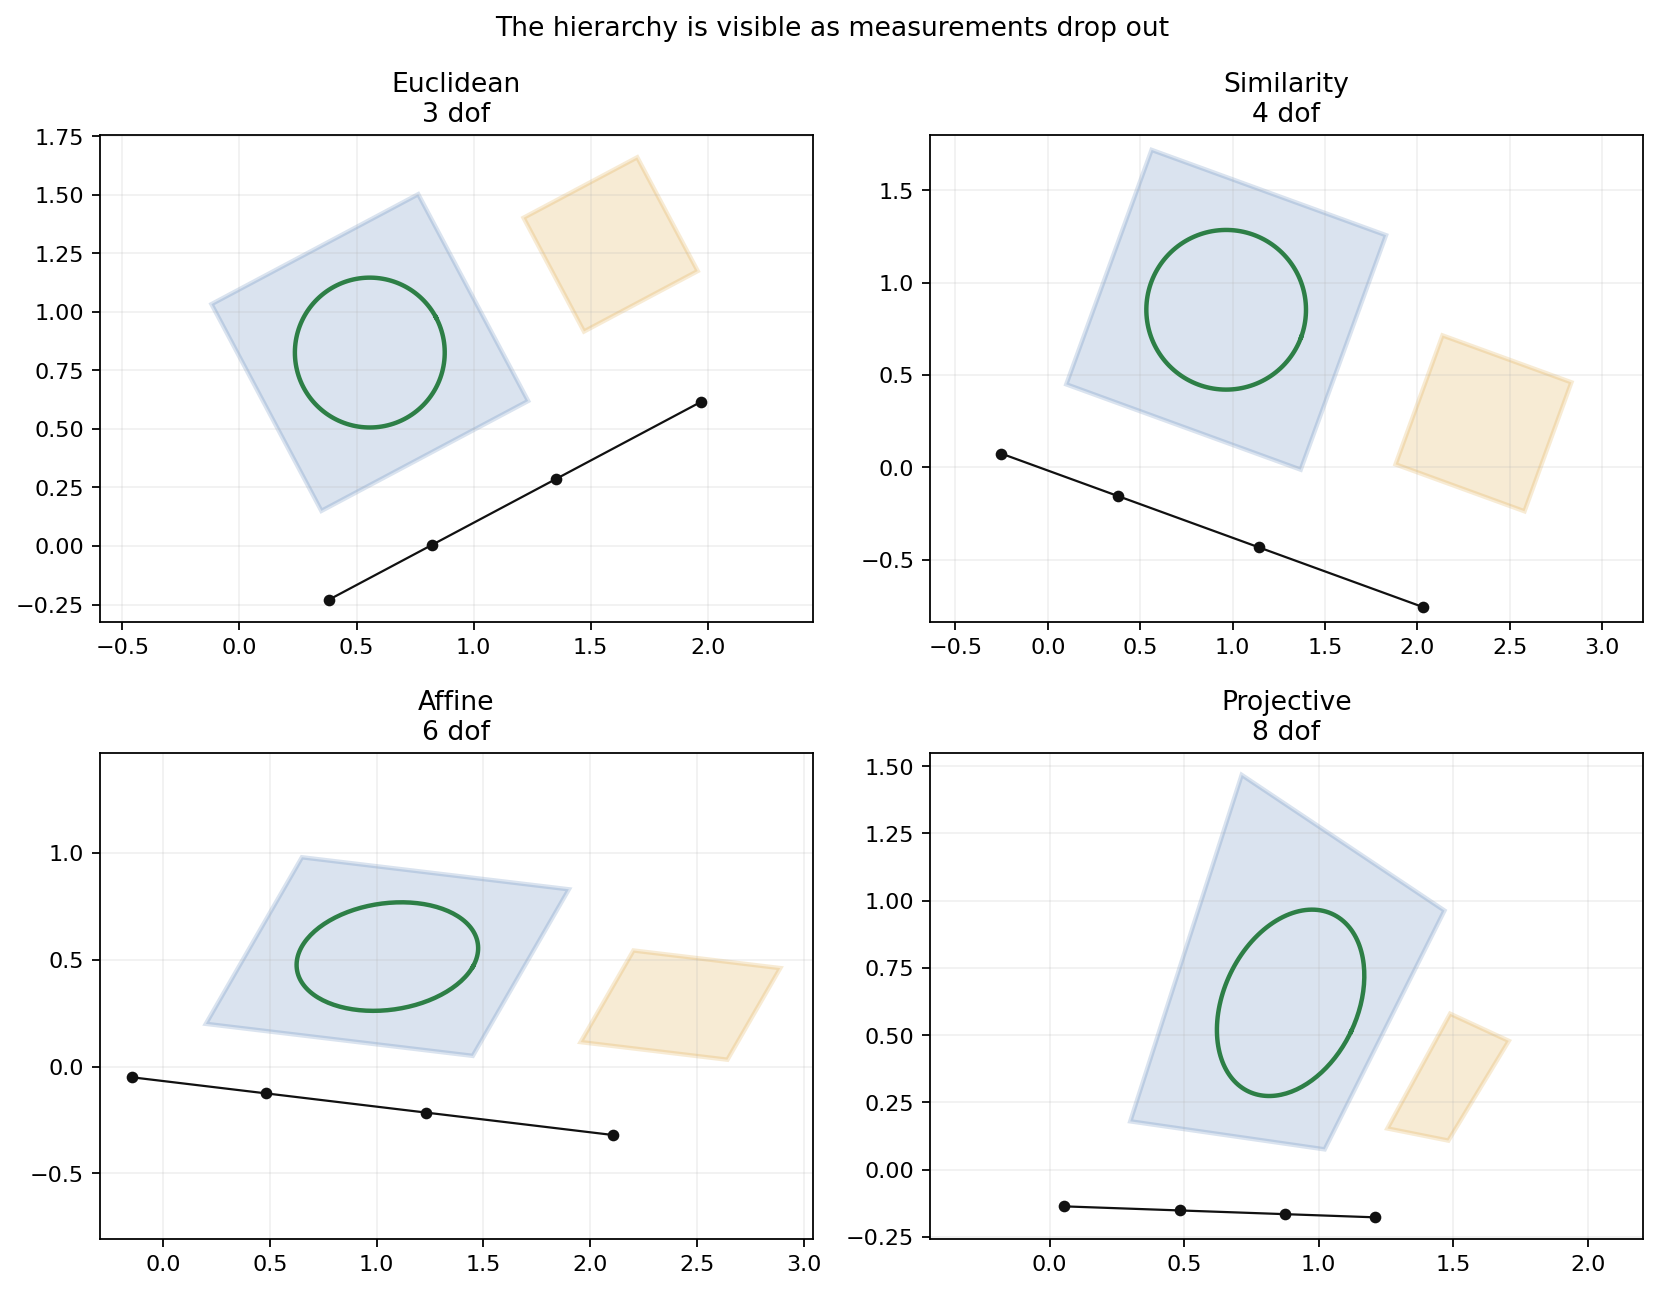

,group,angle_between_square_edges_deg,parallel_intersection_w_over_norm,area_ratio_small_to_large,area_ratio_error,cross_ratio_error
0,Euclidean 3 dof,90.000000,0.000000,0.302500,0.000000,0.0
1,Similarity 4 dof,90.000000,0.000000,0.302500,0.000000,0.0
2,Affine 6 dof,66.861134,0.000000,0.302500,0.000000,0.0
3,Projective 8 dof,71.570649,0.290753,0.112783,0.189717,0.0


`artifacts/chapter-02/checks/transformation_hierarchy_invariants.json`

In [4]:
def rotation(theta):
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[c, -s], [s, c]])


def H_from_A_t(A, t):
    H = np.eye(3)
    H[:2, :2] = A
    H[:2, 2] = t
    return H


transforms = {
    "Euclidean/n3 dof": H_from_A_t(rotation(math.radians(28)), np.array([0.35, 0.15])),
    "Similarity/n4 dof": H_from_A_t(1.35 * rotation(math.radians(-20)), np.array([0.10, 0.45])),
    "Affine/n6 dof": H_from_A_t(np.array([[1.25, 0.45], [-0.15, 0.78]]), np.array([0.20, 0.20])),
    "Projective/n8 dof": np.array([[1.05, 0.25, 0.30], [-0.08, 0.95, 0.18], [0.32, -0.23, 1.0]]),
}

unit_square = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
small_square = 0.55 * unit_square + np.array([1.35, 0.15])
circle = np.column_stack([0.5 + 0.32 * np.cos(np.linspace(0, 2 * np.pi, 160)), 0.5 + 0.32 * np.sin(np.linspace(0, 2 * np.pi, 160))])
line_points = np.array([[-0.15, -0.35], [0.35, -0.35], [0.95, -0.35], [1.65, -0.35]])
source_cr = cross_ratio_collinear(line_points)
source_area_ratio = polygon_area(small_square) / polygon_area(unit_square)

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8.2))
rows = []
for ax, (name, H) in zip(axes.ravel(), transforms.items()):
    square_t = transform_points_2d(H, unit_square)
    small_t = transform_points_2d(H, small_square)
    circle_t = transform_points_2d(H, circle)
    line_t = transform_points_2d(H, line_points)
    ax.fill(square_t[:, 0], square_t[:, 1], alpha=0.18, color="#3266a8", edgecolor="#3266a8", linewidth=2)
    ax.fill(small_t[:, 0], small_t[:, 1], alpha=0.18, color="#d89216", edgecolor="#d89216", linewidth=2)
    ax.plot(circle_t[:, 0], circle_t[:, 1], color="#2d7f46", linewidth=2)
    ax.scatter(line_t[:, 0], line_t[:, 1], color="#111111", s=18, zorder=4)
    ax.plot(line_t[:, 0], line_t[:, 1], color="#111111", linewidth=1)
    ax.set_title(name)
    ax.set_aspect("equal", adjustable="datalim")
    ax.grid(True, alpha=0.18)

    bottom = transform_line(H, join_from_2d(unit_square[0], unit_square[1]))
    top = transform_line(H, join_from_2d(unit_square[3], unit_square[2]))
    right = transform_line(H, join_from_2d(unit_square[1], unit_square[2]))
    adjacent_angle = angle_between_lines(bottom, right)
    parallel_meet = np.cross(bottom, top)
    parallel_w = abs(parallel_meet[2]) / max(np.linalg.norm(parallel_meet), EPS)
    transformed_cr = cross_ratio_collinear(line_t)
    transformed_area_ratio = polygon_area(small_t) / max(polygon_area(square_t), EPS)
    rows.append({
        "group": name.replace("/n", " "),
        "angle_between_square_edges_deg": adjacent_angle,
        "parallel_intersection_w_over_norm": parallel_w,
        "area_ratio_small_to_large": transformed_area_ratio,
        "area_ratio_error": abs(transformed_area_ratio - source_area_ratio),
        "cross_ratio_error": abs(transformed_cr - source_cr),
    })

fig.suptitle("The hierarchy is visible as measurements drop out", y=0.98)
fig.tight_layout()
hierarchy_path = save_matplotlib(fig, TOPIC, "figures", "transformation_hierarchy_invariant_ladder.png")
plt.close(fig)
artifact_paths.append(hierarchy_path)
display_artifact(hierarchy_path, width=880)

hierarchy_df = pd.DataFrame(rows)
hierarchy_checks = {
    "source_cross_ratio": source_cr,
    "source_area_ratio_small_to_large": source_area_ratio,
    "rows": hierarchy_df.to_dict(orient="records"),
}
hierarchy_json_path = save_json(hierarchy_checks, TOPIC, "checks", "transformation_hierarchy_invariants.json")
artifact_paths.append(hierarchy_json_path)
check_registry["transformation_hierarchy"] = hierarchy_checks
display(hierarchy_df.round(8))
display_artifact(hierarchy_json_path)


## Affine Rectification From The Imaged Line At Infinity

A perspective image of a plane is related to the plane by a homography. Parallel world lines meet in the image at vanishing points, and the line through two independent vanishing points is the image of the plane's line at infinity. Sending that line back to `(0,0,1)` removes the projective component, so parallelism and affine ratios can be measured in the rectified chart.


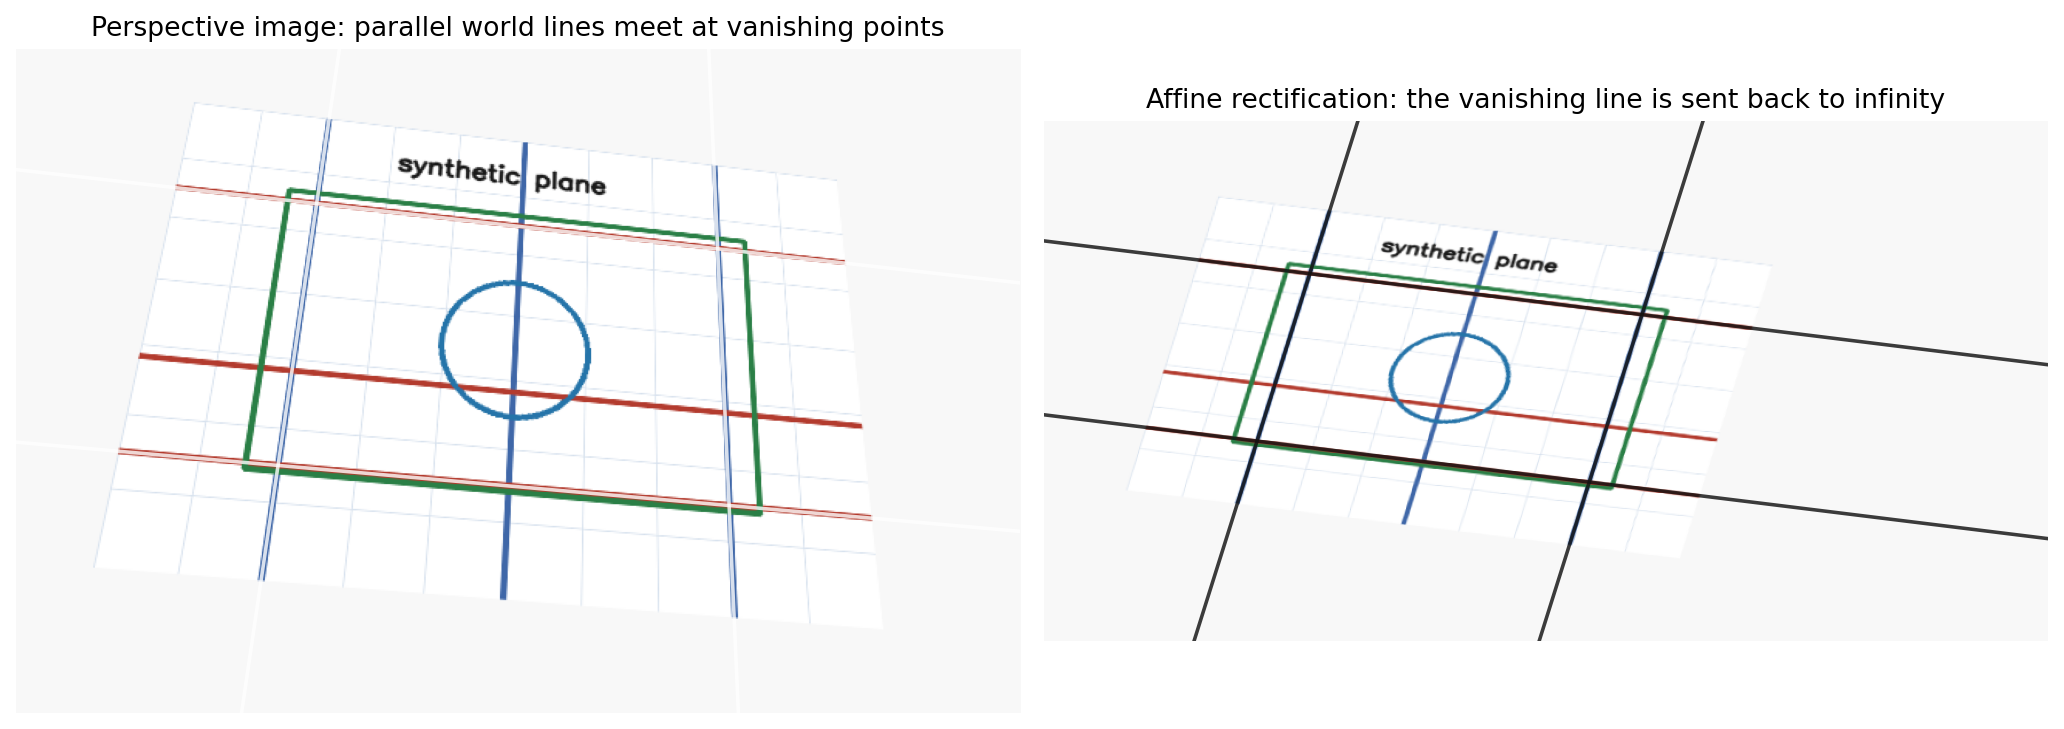

{'vanishing_line_matches_direct_H_inverse_transpose': 1.7536261120299128e-19,
 'rectified_horizontal_parallel_w_over_norm': np.float64(0.0),
 'rectified_vertical_parallel_w_over_norm': np.float64(0.0),
 'rectified_linf_matches_canonical': 0.0}

In [5]:
plane_h, plane_w = 420, 600
plane = np.full((plane_h, plane_w, 3), 255, dtype=np.uint8)
for x in range(0, plane_w, 60):
    cv2.line(plane, (x, 0), (x, plane_h - 1), (216, 226, 238), 1)
for y in range(0, plane_h, 60):
    cv2.line(plane, (0, y), (plane_w - 1, y), (216, 226, 238), 1)
for x in [120, 300, 480]:
    cv2.line(plane, (x, 0), (x, plane_h - 1), (63, 103, 168), 3)
for y in [90, 250, 330]:
    cv2.line(plane, (0, y), (plane_w - 1, y), (179, 59, 46), 3)
cv2.rectangle(plane, (95, 80), (505, 335), (42, 127, 70), 3)
cv2.circle(plane, (300, 210), 62, (37, 116, 169), 3)
cv2.putText(plane, "synthetic plane", (186, 46), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (25, 25, 25), 2, cv2.LINE_AA)

src_corners = np.float32([[0, 0], [plane_w - 1, 0], [plane_w - 1, plane_h - 1], [0, plane_h - 1]])
dst_quad = np.float32([[115, 35], [530, 85], [560, 375], [50, 335]])
H_image = cv2.getPerspectiveTransform(src_corners, dst_quad).astype(float)
perspective = cv2.warpPerspective(plane, H_image, (650, 430), flags=cv2.INTER_LINEAR, borderValue=(248, 248, 248))


def source_horizontal(y):
    return join_from_2d(np.array([0.0, y]), np.array([plane_w - 1.0, y]))


def source_vertical(x):
    return join_from_2d(np.array([x, 0.0]), np.array([x, plane_h - 1.0]))


h_lines_src = [source_horizontal(90), source_horizontal(330)]
v_lines_src = [source_vertical(120), source_vertical(480)]
h_lines_img = [transform_line(H_image, l) for l in h_lines_src]
v_lines_img = [transform_line(H_image, l) for l in v_lines_src]
vp_h = np.cross(h_lines_img[0], h_lines_img[1])
vp_v = np.cross(v_lines_img[0], v_lines_img[1])
linf_from_vanishing_points = np.cross(vp_h, vp_v)
linf_from_transform = transform_line(H_image, linf)
H_affine_rectifier = affine_rectifier_from_line(linf_from_vanishing_points)
affine_rectified, H_affine_canvas = warp_image_with_bounds(perspective, H_affine_rectifier, max_side=820)

h_lines_aff = [transform_line(H_affine_rectifier, l) for l in h_lines_img]
v_lines_aff = [transform_line(H_affine_rectifier, l) for l in v_lines_img]
vp_h_aff = np.cross(h_lines_aff[0], h_lines_aff[1])
vp_v_aff = np.cross(v_lines_aff[0], v_lines_aff[1])
linf_after_rectifier = transform_line(H_affine_rectifier, linf_from_vanishing_points)

affine_checks = {
    "vanishing_line_matches_direct_H_inverse_transpose": proportional_residual(linf_from_vanishing_points, linf_from_transform),
    "rectified_horizontal_parallel_w_over_norm": abs(vp_h_aff[2]) / max(np.linalg.norm(vp_h_aff), EPS),
    "rectified_vertical_parallel_w_over_norm": abs(vp_v_aff[2]) / max(np.linalg.norm(vp_v_aff), EPS),
    "rectified_linf_matches_canonical": proportional_residual(linf_after_rectifier, linf),
}
check_registry["affine_rectification"] = affine_checks

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].imshow(perspective)
axes[0].set_title("Perspective image: parallel world lines meet at vanishing points")
axes[0].axis("off")
for l in h_lines_img + v_lines_img:
    draw_line_on_image_axes(axes[0], l, perspective.shape, color="#ffffff", linewidth=1.6, alpha=0.8)
draw_line_on_image_axes(axes[0], linf_from_vanishing_points, perspective.shape, color="#111111", linewidth=2.2, linestyle="--")

axes[1].imshow(affine_rectified)
axes[1].set_title("Affine rectification: the vanishing line is sent back to infinity")
axes[1].axis("off")
for l in h_lines_img + v_lines_img:
    draw_line_on_image_axes(axes[1], transform_line(H_affine_canvas, l), affine_rectified.shape, color="#111111", linewidth=1.6, alpha=0.82)
fig.tight_layout()
affine_path = save_matplotlib(fig, TOPIC, "figures", "vanishing_line_affine_rectification.png")
plt.close(fig)
artifact_paths.append(affine_path)
display_artifact(affine_path, width=940)
affine_checks


## Metric Rectification From Orthogonal Line Pairs

After affine rectification the line at infinity is fixed, but the circular points are not. The remaining affine distortion is encoded by a symmetric positive definite `2 x 2` matrix. Each known right angle supplies one linear constraint on that matrix. Once the matrix is estimated, its inverse square root removes the anisotropic scaling and leaves only a similarity ambiguity.


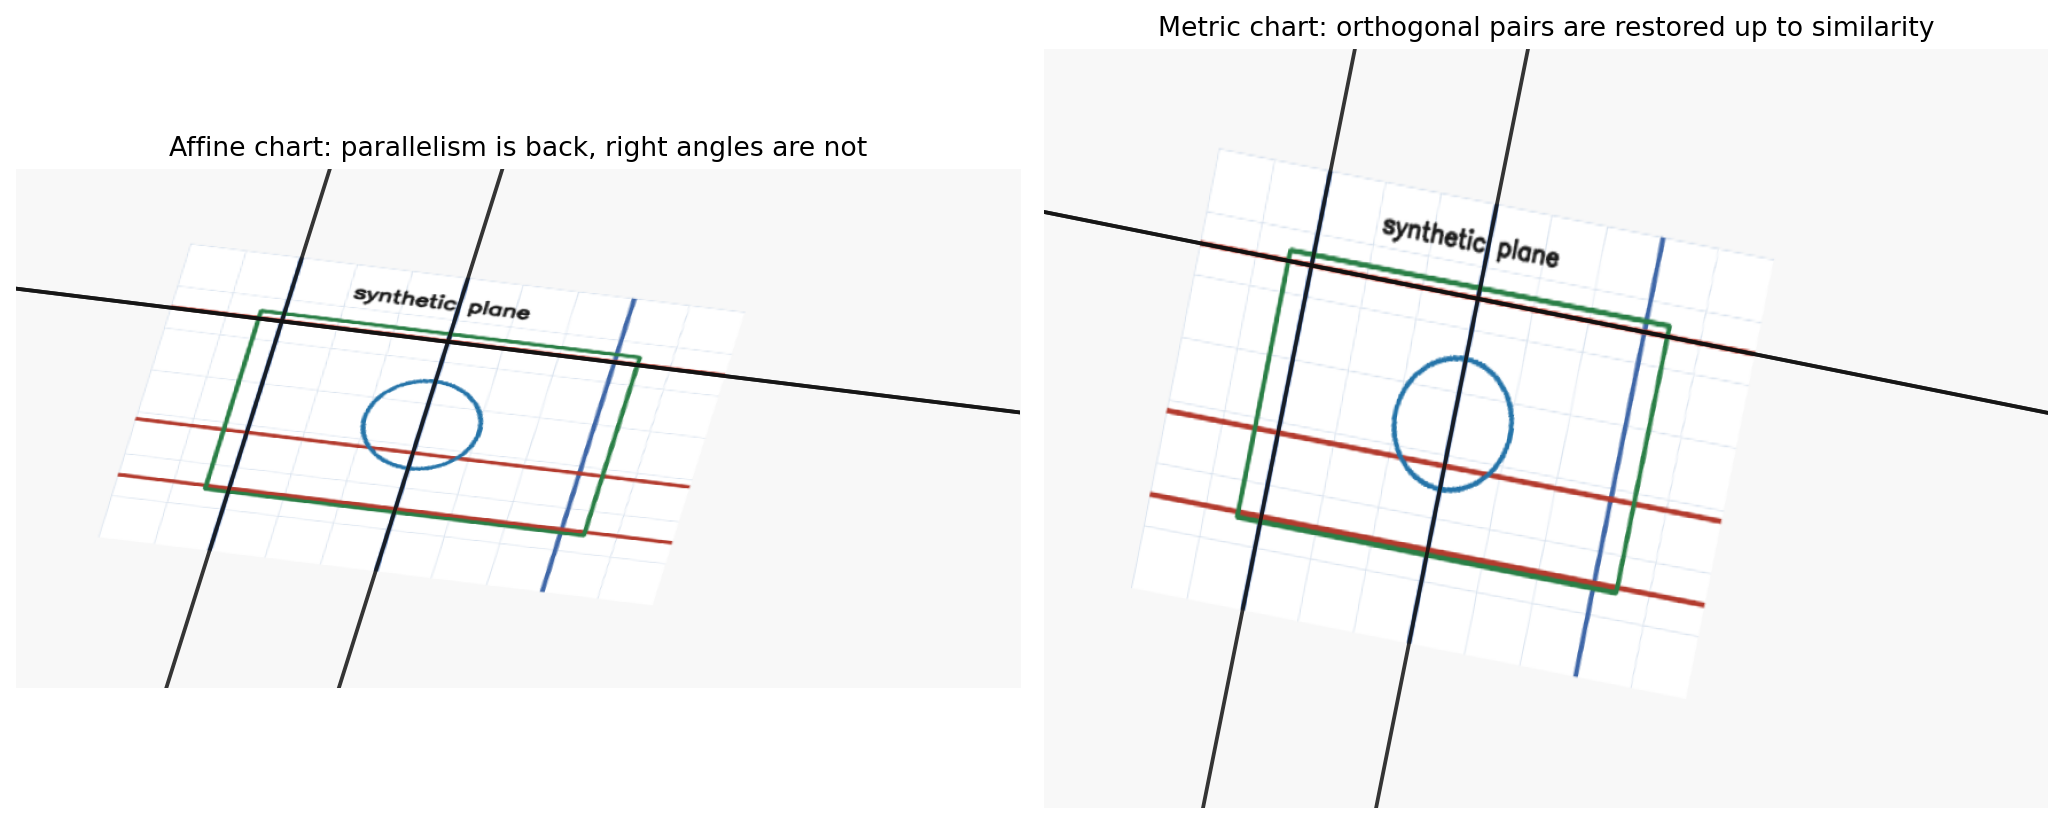

`artifacts/chapter-02/checks/rectification_invariants.json`

{'estimated_S': [[1.5049737425689182, -0.02483194773665592],
  [-0.02483194773665592, 0.6648731451755372]],
 'S_eigenvalues': [0.6641397951124702, 1.5057070926319853],
 'affine_angles_deg_before_metric_step': [79.54193541516288,
  79.54193541516288,
  79.54193541516288,
  79.54193541516288],
 'metric_angles_deg_after_metric_step': [90.0, 90.0, 90.0, 90.0],
 'max_metric_angle_error_deg': 0.0,
 'Cinf_star_image_singular_values': [0.5926206486893565,
  0.3230588799050322,
  0.0],
 'Cinf_star_image_rank2_smallest_singular_value': 0.0,
 'Cinf_star_null_line_matches_vanishing_line': 1.6173614979517535e-19,
 'perspective_angle_from_dual_conic_deg': 90.0}

In [6]:
orthogonal_source_pairs = [
    (source_vertical(120), source_horizontal(90)),
    (source_vertical(300), source_horizontal(90)),
    (source_vertical(120), source_horizontal(250)),
    (source_vertical(480), source_horizontal(330)),
]
H_source_to_affine = H_affine_rectifier @ H_image
constraints = []
for l_src, m_src in orthogonal_source_pairs:
    l_aff = transform_line(H_source_to_affine, l_src)
    m_aff = transform_line(H_source_to_affine, m_src)
    constraints.append([l_aff[0] * m_aff[0], l_aff[0] * m_aff[1] + l_aff[1] * m_aff[0], l_aff[1] * m_aff[1]])
constraints = np.asarray(constraints, dtype=float)
_, _, vt = np.linalg.svd(constraints)
s = vt[-1]
S_metric = np.array([[s[0], s[1]], [s[1], s[2]]], dtype=float)
if np.all(np.linalg.eigvalsh(S_metric) < 0):
    S_metric = -S_metric
S_metric = S_metric / np.linalg.det(S_metric) ** 0.5
B_metric = inverse_sqrt_spd(S_metric)
H_metric_from_affine = np.array([[B_metric[0, 0], B_metric[0, 1], 0.0], [B_metric[1, 0], B_metric[1, 1], 0.0], [0.0, 0.0, 1.0]])
H_metric_rectifier = H_metric_from_affine @ H_affine_rectifier
metric_rectified, H_metric_canvas = warp_image_with_bounds(perspective, H_metric_rectifier, max_side=820)
H_source_to_metric = H_metric_rectifier @ H_image

metric_angles = []
affine_angles = []
for l_src, m_src in orthogonal_source_pairs:
    l_aff = transform_line(H_source_to_affine, l_src)
    m_aff = transform_line(H_source_to_affine, m_src)
    l_met = transform_line(H_source_to_metric, l_src)
    m_met = transform_line(H_source_to_metric, m_src)
    affine_angles.append(angle_between_lines(l_aff, m_aff))
    metric_angles.append(angle_between_lines(l_met, m_met))

Cinf_star = np.diag([1.0, 1.0, 0.0])
Cinf_star_image = transform_dual_conic(H_image, Cinf_star)
rank_singular_values = np.linalg.svd(Cinf_star_image, compute_uv=False)
angle_in_perspective = angle_from_dual_conic(h_lines_img[0], v_lines_img[0], Cinf_star_image)

metric_checks = {
    "estimated_S": S_metric.tolist(),
    "S_eigenvalues": np.linalg.eigvalsh(S_metric).tolist(),
    "affine_angles_deg_before_metric_step": affine_angles,
    "metric_angles_deg_after_metric_step": metric_angles,
    "max_metric_angle_error_deg": float(max(abs(a - 90.0) for a in metric_angles)),
    "Cinf_star_image_singular_values": rank_singular_values.tolist(),
    "Cinf_star_image_rank2_smallest_singular_value": float(rank_singular_values[-1]),
    "Cinf_star_null_line_matches_vanishing_line": proportional_residual(np.linalg.svd(Cinf_star_image)[2][-1], linf_from_vanishing_points),
    "perspective_angle_from_dual_conic_deg": angle_in_perspective,
}
rectification_json_path = save_json({"affine": affine_checks, "metric": metric_checks}, TOPIC, "checks", "rectification_invariants.json")
artifact_paths.append(rectification_json_path)
check_registry["metric_rectification"] = metric_checks

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
axes[0].imshow(affine_rectified)
axes[0].set_title("Affine chart: parallelism is back, right angles are not")
axes[0].axis("off")
for l_src, m_src in orthogonal_source_pairs[:2]:
    for l in [transform_line(H_affine_canvas @ H_image, l_src), transform_line(H_affine_canvas @ H_image, m_src)]:
        draw_line_on_image_axes(axes[0], l, affine_rectified.shape, color="#111111", linewidth=1.7, alpha=0.85)
axes[1].imshow(metric_rectified)
axes[1].set_title("Metric chart: orthogonal pairs are restored up to similarity")
axes[1].axis("off")
for l_src, m_src in orthogonal_source_pairs[:2]:
    for l in [transform_line(H_metric_canvas @ H_image, l_src), transform_line(H_metric_canvas @ H_image, m_src)]:
        draw_line_on_image_axes(axes[1], l, metric_rectified.shape, color="#111111", linewidth=1.7, alpha=0.85)
fig.tight_layout()
metric_path = save_matplotlib(fig, TOPIC, "figures", "orthogonal_line_metric_rectification.png")
plt.close(fig)
artifact_paths.append(metric_path)
display_artifact(metric_path, width=940)
display_artifact(rectification_json_path)
metric_checks


## Conics, Tangents, And The Pole-Polar Map

A point conic is a symmetric matrix `C`. If `x` lies on the conic, `C @ x` is the tangent line at `x`. For a point outside the conic, `C @ x` is its polar line: the two tangent contact points lie on that line, and the tangents at those contact points meet at the original point.


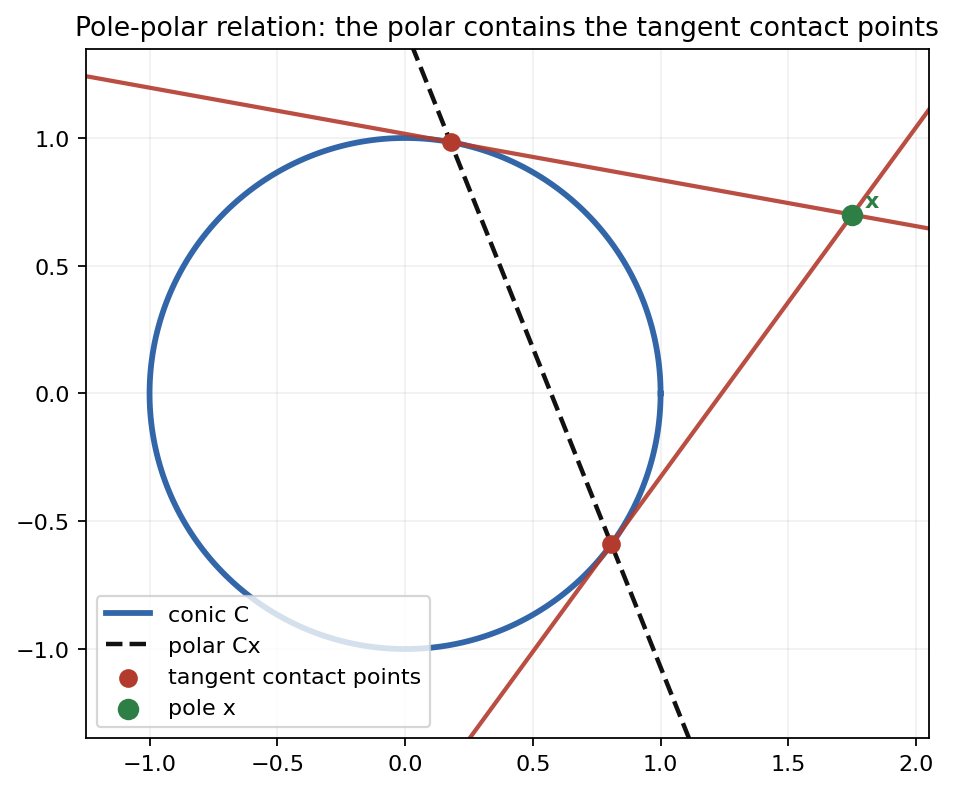

`artifacts/chapter-02/checks/conic_pole_polar_invariants.json`

{'sympy_circle_conic_equation': 'x**2 + y**2 - 1',
 'contact_checks': [{'point_on_conic': 0.0,
   'contact_on_polar': 0.0,
   'external_point_on_tangent': 0.0},
  {'point_on_conic': 0.0,
   'contact_on_polar': 7.358685639414011e-17,
   'external_point_on_tangent': 7.358685639414011e-17}],
 'polar_transform_residual': 9.21568574630745e-17,
 'conjugacy_symmetry_residual': 0.0}

In [7]:
C_circle = np.diag([1.0, 1.0, -1.0])
external_point = np.array([1.75, 0.70, 1.0])
polar_line = C_circle @ external_point
u, v, c = polar_line
normal_sq = u * u + v * v
foot = -c * np.array([u, v]) / normal_sq
distance_to_origin = abs(c) / math.sqrt(normal_sq)
half_chord = math.sqrt(max(0.0, 1.0 - distance_to_origin**2))
direction = np.array([-v, u]) / math.sqrt(normal_sq)
contact_points_2d = np.vstack([foot + half_chord * direction, foot - half_chord * direction])
contact_points = homog(contact_points_2d)
tangent_lines = [(C_circle @ p) for p in contact_points]

x_sym, y_sym = sp.symbols("x y", real=True)
C_sym = sp.diag(1, 1, -1)
p_sym = sp.Matrix([x_sym, y_sym, 1])
conic_equation_sym = sp.expand((p_sym.T * C_sym * p_sym)[0])

H_conic_demo = np.array([[1.0, 0.25, 0.20], [-0.10, 1.15, 0.05], [0.08, -0.04, 1.0]])
C_transformed = transform_conic(H_conic_demo, C_circle)
external_transformed = H_conic_demo @ external_point
polar_transformed_from_conic = C_transformed @ external_transformed
polar_transformed_from_line = transform_line(H_conic_demo, polar_line)

tangent_checks = []
for p, l in zip(contact_points, tangent_lines):
    tangent_checks.append({
        "point_on_conic": float(abs(p.T @ C_circle @ p)),
        "contact_on_polar": incidence_residual(polar_line, p),
        "external_point_on_tangent": incidence_residual(l, external_point),
    })

conic_checks = {
    "sympy_circle_conic_equation": str(conic_equation_sym),
    "contact_checks": tangent_checks,
    "polar_transform_residual": proportional_residual(polar_transformed_from_conic, polar_transformed_from_line),
    "conjugacy_symmetry_residual": float(abs(external_point.T @ C_circle @ contact_points[0] - contact_points[0].T @ C_circle @ external_point)),
}
conic_json_path = save_json(conic_checks, TOPIC, "checks", "conic_pole_polar_invariants.json")
artifact_paths.append(conic_json_path)
check_registry["conic_pole_polar"] = conic_checks

fig, ax = plt.subplots(figsize=(6.8, 6.2))
theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), color="#3266a8", linewidth=2.6, label="conic C")
seg = segment_for_line(polar_line, (-1.25, 2.05), (-1.35, 1.35))
if seg is not None:
    ax.plot(seg[:, 0], seg[:, 1], color="#111111", linestyle="--", linewidth=2, label="polar Cx")
for l in tangent_lines:
    seg = segment_for_line(l, (-1.25, 2.05), (-1.35, 1.35))
    if seg is not None:
        ax.plot(seg[:, 0], seg[:, 1], color="#b33b2e", linewidth=1.9, alpha=0.9)
ax.scatter(contact_points_2d[:, 0], contact_points_2d[:, 1], color="#b33b2e", s=55, zorder=5, label="tangent contact points")
ax.scatter([external_point[0]], [external_point[1]], color="#2d7f46", s=75, zorder=6, label="pole x")
ax.text(external_point[0] + 0.05, external_point[1] + 0.03, "x", color="#2d7f46", weight="bold")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.25, 2.05)
ax.set_ylim(-1.35, 1.35)
ax.set_title("Pole-polar relation: the polar contains the tangent contact points")
ax.legend(loc="lower left")
conic_path = save_matplotlib(fig, TOPIC, "figures", "conic_pole_polar_tangency.png")
plt.close(fig)
artifact_paths.append(conic_path)
display_artifact(conic_path, width=720)
display_artifact(conic_json_path)
conic_checks


## Fixed Points And Fixed Lines Of A Homography

When the source and destination plane are identified, a fixed point is an eigenvector of `H`: the vector may be rescaled, but the projective point is unchanged. Fixed lines are eigenvectors of `H.T` equivalently, because lines move by `H^{-T}`. With three distinct eigenpoints, the joining lines are fixed as sets even though most points on those lines move along the line.


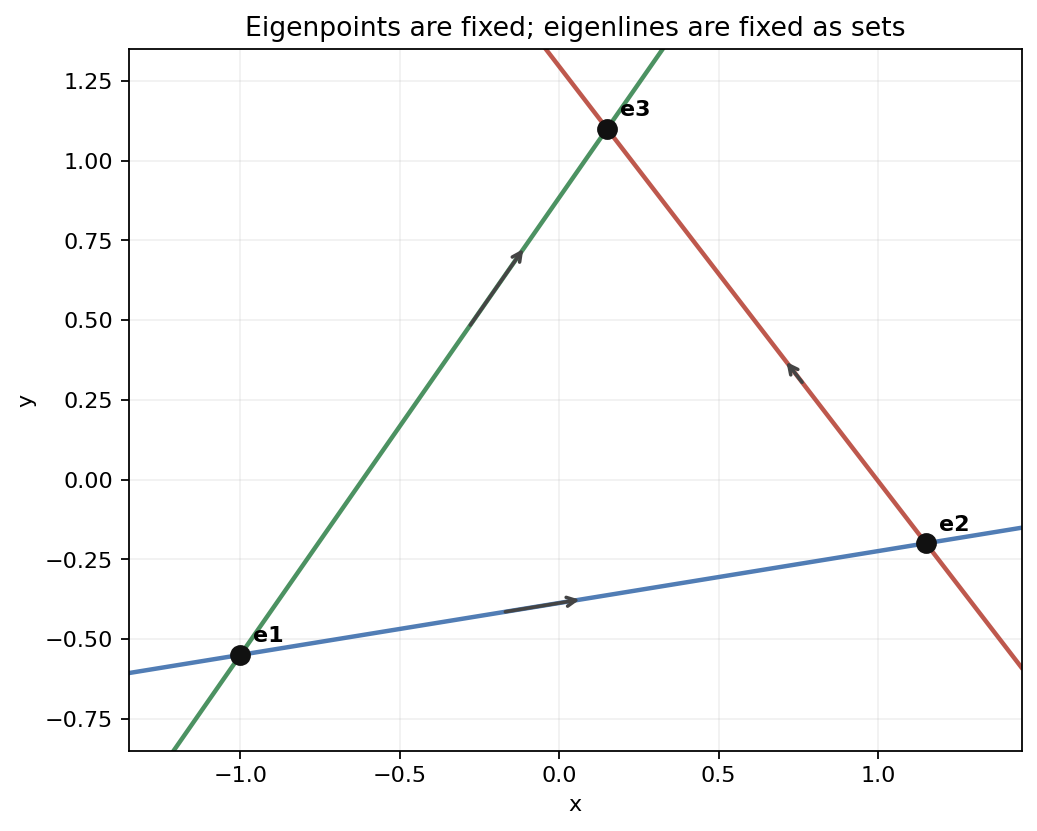

{'fixed_point_projective_residuals': [0.0,
  8.210145813868242e-17,
  1.3057198598079762e-16],
 'fixed_line_projective_residuals': [1.5822249798988318e-17,
  5.17728462856209e-17,
  2.20324997593037e-16],
 'max_fixed_point_residual': 1.3057198598079762e-16,
 'max_fixed_line_residual': 2.20324997593037e-16}

In [8]:
eigen_points = homog(np.array([[-1.0, -0.55], [1.15, -0.20], [0.15, 1.10]]))
E = eigen_points.T
eigen_values = np.diag([0.72, 1.18, 1.55])
H_fixed = E @ eigen_values @ np.linalg.inv(E)
fixed_lines = [np.cross(eigen_points[i], eigen_points[j]) for i, j in [(0, 1), (1, 2), (2, 0)]]

fixed_point_residuals = [proportional_residual(H_fixed @ p, p) for p in eigen_points]
fixed_line_residuals = [proportional_residual(transform_line(H_fixed, l), l) for l in fixed_lines]

fig, ax = plt.subplots(figsize=(7.2, 6.2))
xy = dehomog(eigen_points)
ax.scatter(xy[:, 0], xy[:, 1], s=70, color="#111111", zorder=5)
for i, point in enumerate(xy, start=1):
    ax.text(point[0] + 0.04, point[1] + 0.04, f"e{i}", weight="bold")
for l, color in zip(fixed_lines, ["#3266a8", "#b33b2e", "#2d7f46"]):
    seg = segment_for_line(l, (-1.35, 1.45), (-0.85, 1.35))
    if seg is not None:
        ax.plot(seg[:, 0], seg[:, 1], color=color, linewidth=2.0, alpha=0.85)
for i, j in [(0, 1), (1, 2), (2, 0)]:
    sample = 0.62 * eigen_points[i] + 0.38 * eigen_points[j]
    sample = sample / sample[2]
    moved = H_fixed @ sample
    sample_xy = dehomog(sample.reshape(1, 3))[0]
    moved_xy = dehomog(moved.reshape(1, 3))[0]
    ax.annotate("", xy=moved_xy, xytext=sample_xy, arrowprops=dict(arrowstyle="->", color="#444444", lw=1.6))
ax.set_title("Eigenpoints are fixed; eigenlines are fixed as sets")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.35, 1.45)
ax.set_ylim(-0.85, 1.35)
ax.set_xlabel("x")
ax.set_ylabel("y")
fixed_path = save_matplotlib(fig, TOPIC, "figures", "fixed_points_and_fixed_lines.png")
plt.close(fig)
artifact_paths.append(fixed_path)

fixed_checks = {
    "fixed_point_projective_residuals": fixed_point_residuals,
    "fixed_line_projective_residuals": fixed_line_residuals,
    "max_fixed_point_residual": max(fixed_point_residuals),
    "max_fixed_line_residual": max(fixed_line_residuals),
}
check_registry["fixed_points_and_lines"] = fixed_checks
display_artifact(fixed_path, width=760)
fixed_checks


## Applied Lab: How Noisy Vanishing Lines Affect Affine Rectification

The previous rectification examples used exact synthetic lines. Real image measurements are endpoints, not mathematical lines. This lab perturbs the endpoints used to estimate two vanishing points and records how the recovered vanishing line drifts. The output is a small CSV artifact rather than a new theory: it tells you which residuals to watch when you repeat the construction on real image measurements.


In [9]:
def noisy_line_from_source_segment(p, q, sigma):
    endpoints = transform_points_2d(H_image, np.vstack([p, q]))
    noisy = endpoints + rng.normal(scale=sigma, size=endpoints.shape)
    return join_from_2d(noisy[0], noisy[1])


source_endpoint_pairs = {
    "h1": (np.array([0.0, 90.0]), np.array([plane_w - 1.0, 90.0])),
    "h2": (np.array([0.0, 330.0]), np.array([plane_w - 1.0, 330.0])),
    "v1": (np.array([120.0, 0.0]), np.array([120.0, plane_h - 1.0])),
    "v2": (np.array([480.0, 0.0]), np.array([480.0, plane_h - 1.0])),
}

noise_rows = []
for sigma in [0.0, 0.5, 1.0, 2.0, 4.0]:
    line_errors = []
    parallel_residuals = []
    for _ in range(40):
        lh1 = noisy_line_from_source_segment(*source_endpoint_pairs["h1"], sigma)
        lh2 = noisy_line_from_source_segment(*source_endpoint_pairs["h2"], sigma)
        lv1 = noisy_line_from_source_segment(*source_endpoint_pairs["v1"], sigma)
        lv2 = noisy_line_from_source_segment(*source_endpoint_pairs["v2"], sigma)
        vh = np.cross(lh1, lh2)
        vv = np.cross(lv1, lv2)
        l_est = np.cross(vh, vv)
        if abs(l_est[2]) < 1e-9:
            continue
        H_est = affine_rectifier_from_line(l_est)
        h_after = [transform_line(H_est, l) for l in h_lines_img]
        v_after = [transform_line(H_est, l) for l in v_lines_img]
        vh_after = np.cross(h_after[0], h_after[1])
        vv_after = np.cross(v_after[0], v_after[1])
        line_errors.append(proportional_residual(l_est, linf_from_vanishing_points))
        parallel_residuals.append(max(abs(vh_after[2]) / max(np.linalg.norm(vh_after), EPS), abs(vv_after[2]) / max(np.linalg.norm(vv_after), EPS)))
    noise_rows.append({
        "endpoint_noise_px": sigma,
        "median_vanishing_line_residual": float(np.median(line_errors)),
        "p90_vanishing_line_residual": float(np.percentile(line_errors, 90)),
        "median_parallel_w_over_norm_after_rectification": float(np.median(parallel_residuals)),
    })

noise_df = pd.DataFrame(noise_rows)
noise_csv_path = save_csv(noise_rows, TOPIC, "tables", "affine_rectification_noise_sensitivity.csv")
artifact_paths.append(noise_csv_path)
check_registry["noise_lab"] = noise_rows
display(noise_df)
display_artifact(noise_csv_path)


,endpoint_noise_px,median_vanishing_line_residual,p90_vanishing_line_residual,median_parallel_w_over_norm_after_rectification
0,0.0,5.078482e-19,5.078482e-19,3.930741e-19
1,0.5,1.536587e-05,2.898146e-05,1.284378e-05
2,1.0,2.403895e-05,4.613095e-05,2.211106e-05
3,2.0,7.637839e-05,1.234940e-04,6.941547e-05
4,4.0,1.462955e-04,2.641837e-04,1.232693e-04


[affine_rectification_noise_sensitivity.csv](Multiple-View-Geometry-in-Computer-Vision/artifacts/chapter-02/tables/affine_rectification_noise_sensitivity.csv)

## Final Sanity Checks

These checks are deliberately mathematical. They assert incidence, line transport, cross-ratio invariance, transformation hierarchy behavior, rectification residuals, conic tangency, fixed eigenstructure, and artifact integrity. A notebook can render attractive pictures while still being geometrically wrong; these residuals are the guardrail.


In [10]:
summary_checks = {
    "homogeneous_max_incidence": check_registry["homogeneous_incidence_vanishing_line"]["max_transformed_endpoint_incidence"],
    "vanishing_line_residual": check_registry["homogeneous_incidence_vanishing_line"]["vanishing_line_matches_H_inverse_transpose"],
    "homography_cross_ratio_error": check_registry["homography_grid_cross_ratio"]["cross_ratio_absolute_error"],
    "homography_collinearity_residual": check_registry["homography_grid_cross_ratio"]["max_grid_endpoint_line_incidence"],
    "affine_rectified_linf_residual": check_registry["affine_rectification"]["rectified_linf_matches_canonical"],
    "affine_rectified_parallel_residual": max(
        check_registry["affine_rectification"]["rectified_horizontal_parallel_w_over_norm"],
        check_registry["affine_rectification"]["rectified_vertical_parallel_w_over_norm"],
    ),
    "metric_max_angle_error_deg": check_registry["metric_rectification"]["max_metric_angle_error_deg"],
    "metric_Cinf_rank_residual": check_registry["metric_rectification"]["Cinf_star_image_rank2_smallest_singular_value"],
    "conic_polar_transform_residual": check_registry["conic_pole_polar"]["polar_transform_residual"],
    "fixed_point_residual": check_registry["fixed_points_and_lines"]["max_fixed_point_residual"],
    "fixed_line_residual": check_registry["fixed_points_and_lines"]["max_fixed_line_residual"],
    "zero_noise_vanishing_line_residual": check_registry["noise_lab"][0]["median_vanishing_line_residual"],
}

assert summary_checks["homogeneous_max_incidence"] < 1e-10
assert summary_checks["vanishing_line_residual"] < 1e-10
assert summary_checks["homography_cross_ratio_error"] < 1e-10
assert summary_checks["homography_collinearity_residual"] < 1e-10
assert summary_checks["affine_rectified_linf_residual"] < 1e-10
assert summary_checks["affine_rectified_parallel_residual"] < 1e-8
assert summary_checks["metric_max_angle_error_deg"] < 1e-7
assert summary_checks["metric_Cinf_rank_residual"] < 1e-7
assert summary_checks["conic_polar_transform_residual"] < 1e-10
assert summary_checks["fixed_point_residual"] < 1e-10
assert summary_checks["fixed_line_residual"] < 1e-10
assert summary_checks["zero_noise_vanishing_line_residual"] < 1e-10

sanity = {
    "source_span": "printed pages 25-64; PDF pages 43-82",
    "artifact_count_before_sanity_file": len(artifact_paths),
    "artifacts": [relative_to_book(path, BOOK_ROOT) for path in artifact_paths],
    "checks": summary_checks,
}
final_sanity = sanity
sanity_path = save_json(sanity, TOPIC, "checks", "projective_geometry_2d_sanity.json")
artifact_paths.append(sanity_path)
assert_artifacts(artifact_paths, min_bytes=64)
for path in artifact_paths:
    assert path.exists(), path
    assert path.stat().st_size > 64, path

display_artifact(sanity_path)
sanity


`artifacts/chapter-02/checks/projective_geometry_2d_sanity.json`

{'source_span': 'printed pages 25-64; PDF pages 43-82',
 'artifact_count_before_sanity_file': 11,
 'artifacts': ['artifacts/chapter-02/figures/homogeneous_incidence_vanishing_line.png',
  'artifacts/chapter-02/interactive/homography_grid_cross_ratio.html',
  'artifacts/chapter-02/figures/transformation_hierarchy_invariant_ladder.png',
  'artifacts/chapter-02/checks/transformation_hierarchy_invariants.json',
  'artifacts/chapter-02/figures/vanishing_line_affine_rectification.png',
  'artifacts/chapter-02/checks/rectification_invariants.json',
  'artifacts/chapter-02/figures/orthogonal_line_metric_rectification.png',
  'artifacts/chapter-02/checks/conic_pole_polar_invariants.json',
  'artifacts/chapter-02/figures/conic_pole_polar_tangency.png',
  'artifacts/chapter-02/figures/fixed_points_and_fixed_lines.png',
  'artifacts/chapter-02/tables/affine_rectification_noise_sensitivity.csv'],
 'checks': {'homogeneous_max_incidence': 1.1269543052411977e-16,
  'vanishing_line_residual': 6.3380434

## Takeaways

- Homogeneous coordinates make parallel-line intersections, line joins, and point-line incidence uniform.
- Points and lines transform differently: points use `H`, while lines use `H^{-T}`.
- The cross-ratio is the basic projective invariant on a line; ordinary lengths and angles require stronger structure.
- The line at infinity carries affine structure. Recovering its image gives affine rectification.
- The circular points, equivalently their dual conic, carry metric structure. Orthogonal-line constraints can recover that structure up to a similarity.
- Conic polarity and fixed eigenstructure are not side topics: they are the same homogeneous algebra acting on different geometric objects.
